Time axis values sorted in ascending order
Time axis values sorted in ascending order


Initial density is 0.0003
Initial density is not within the tolerance window, searching...
Epsilon: 1.4970, Density: 0.0018
Epsilon: 1.9787, Density: 0.0062
Epsilon: 2.4169, Density: 0.0123
Epsilon: 2.7937, Density: 0.0186
Epsilon: 3.1080, Density: 0.0244
Epsilon: 3.3643, Density: 0.0297


Epsilon: 3.5676, Density: 0.0344
Epsilon: 3.7239, Density: 0.0383
Epsilon: 3.8409, Density: 0.0414
Epsilon: 3.8409, Density: 0.0414.


Deterministic Transition Detection Results - NGRIP Ice Core Data
+----------+---------------------+----------------+------------------+---------------------+
| Method   |   Total Transitions |   Upward Jumps |   Downward Jumps | Series Label        |
+==========+=====================+================+==================+=====================+
| LERM     |                  29 |             14 |               15 | NGRIP Ice Core Data |
+----------+---------------------+----------------+------------------+---------------------+

Transition Details:
  1. Time: 9.43 kyr b2k, Direction: Upward
  2. Time: 10.43 kyr b2k, Direction: Downward
  3. Time: 11.43 kyr b2k, Direction: Upward
  4. Time: 13.43 kyr b2k, Direction: Downward
  5. Time: 15.43 kyr b2k, Direction: Upward
  6. Time: 26.43 kyr b2k, Direction: Downward
  7. Time: 29.43 kyr b2k, Direction: Upward
  8. Time: 30.43 kyr b2k, Direction: Downward
  9. Time: 32.43 kyr b2k, Direction: Downward
  10. Time: 40.43 kyr b2k, Direction: Upward

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Transition Detection - NGRIP Ice Core Data'}, xlabel='Age [kyr b2k]', ylabel='Fisher Information'>)

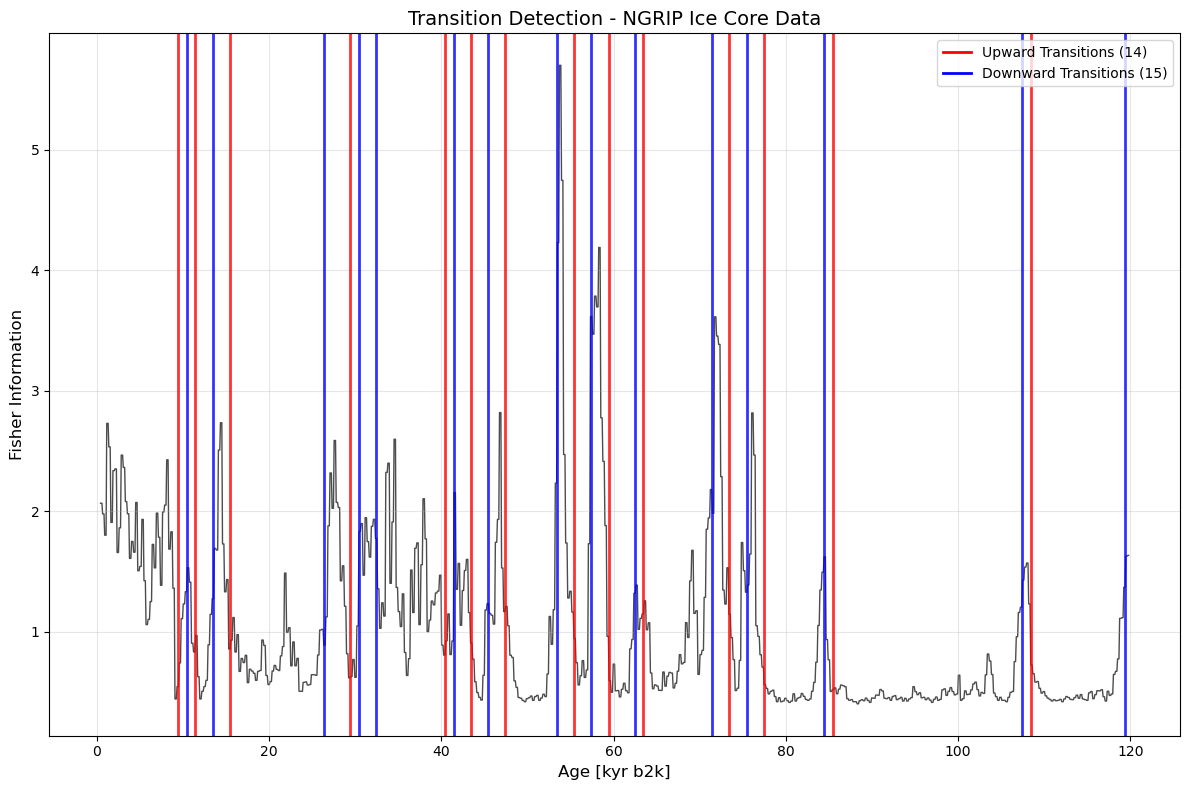

In [1]:
import os, ammonyte as amt

# Load data
ngrip = amt.Series.from_csv(os.path.join(os.path.dirname(amt.__file__), 'data', 'NGRIP.csv'))

# LERM analysis
NGRIP_td = amt.TimeEmbeddedSeries(ngrip, m=11)
NGRIP_epsilon = NGRIP_td.find_epsilon(eps=1, target_density=0.05)
NGRIP_rm = NGRIP_epsilon['Output']
NGRIP_lp = NGRIP_rm.laplacian_eigenmaps(w_size=20, w_incre=4)
NGRIP_lp_smooth = amt.utils.fisher.smooth_series(NGRIP_lp, block_size=3)

# Detect transitions
transitions = NGRIP_lp_smooth.lerm_transitions()
print(transitions)
transitions.plot()

In [2]:
transitions = NGRIP_lp_smooth.lerm_transitions(
    transition_interval=(0.025, 0.010)
)

In [3]:
import os, ammonyte as amt
ngrip = amt.Series.from_csv(os.path.join(os.path.dirname(amt.__file__), 'data', 'NGRIP.csv'))
transitions = ngrip.kstest(w_min=0.12, w_max=2.5, n_w=15, d_c=0.77, n_c=3, s_c=2, x_c=0.8)
print(transitions)

Time axis values sorted in ascending order
Time axis values sorted in ascending order


Deterministic Transition Detection Results - NGRIP Ice Core Data
+----------+---------------------+----------------+------------------+---------------------+
| Method   |   Total Transitions |   Upward Jumps |   Downward Jumps | Series Label        |
+==========+=====================+================+==================+=====================+
| KS test  |                 104 |             49 |               55 | NGRIP Ice Core Data |
+----------+---------------------+----------------+------------------+---------------------+

Transition Details:
  1. Time: 8.14 kyr b2k, Direction: Upward, d_statistics: 0.4080, p_values: < 1e-8
  2. Time: 8.30 kyr b2k, Direction: Downward, d_statistics: 0.3760, p_values: < 1e-7
  3. Time: 10.20 kyr b2k, Direction: Upward, d_statistics: 0.9203, p_values: < 1e-56
  4. Time: 10.86 kyr b2k, Direction: Upward, d_statistics: 0.9680, p_values: < 1e-65
  5. Time: 11.52 kyr b2k, Direction: Downward, d_statistics: 0.9040, p_values: < 1e-53
  6. Time: 11.68 kyr b2k

In [4]:
print(f"D-statistics: {transitions.d_statistics}")
print(f"P-values: {transitions.p_values}")

D-statistics: [0.408      0.376      0.92031746 0.968      0.904      0.952
 0.352      0.216      0.264      0.376      0.424      0.616
 0.432      0.16       0.48       0.264      0.2        0.288
 0.232      0.312      0.464      0.25961905 0.488      0.31574603
 0.352      0.344      0.152      0.208      0.232      0.232
 0.56       0.224      0.216      0.544      0.216      0.296
 0.216      0.144      0.488      0.344      0.584      0.472
 0.52       0.536      0.536      0.624      0.752      0.768
 0.456      0.232      0.216      0.512      0.424      0.408
 0.528      0.696      0.784      0.72       0.776      0.248
 0.168      0.12920635 0.12       0.16       0.296      0.592
 0.544      0.624      0.504      0.52       0.696      0.552
 0.504      0.52       0.672      0.552      0.512      0.272
 0.84       0.976      0.864      0.888      0.872      0.512
 0.584      0.264      0.456      0.432      0.632      0.48
 0.488      0.448      0.296      0.312      0.36   

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Transition Detection - NGRIP Ice Core Data'}, xlabel='Age [kyr b2k]', ylabel='δ¹⁸O [‰]'>)

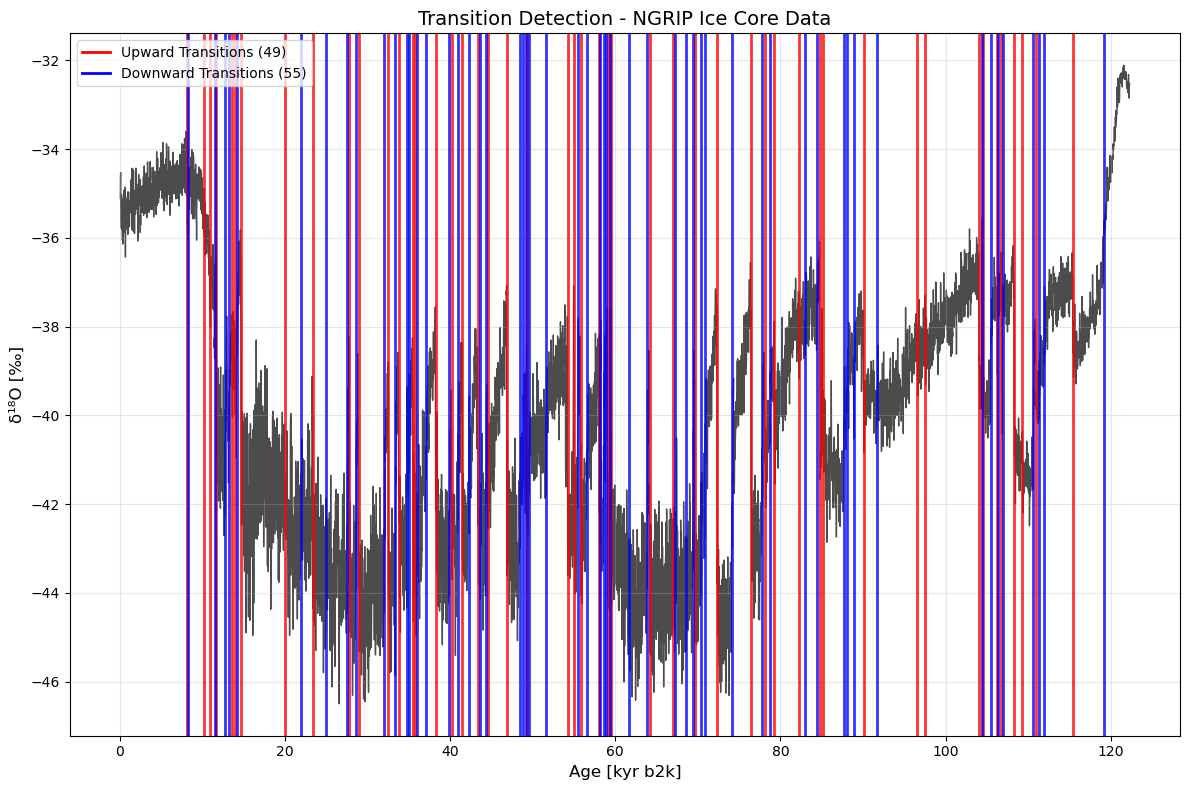

In [5]:
transitions.plot()

In [6]:
import os, ammonyte as amt
ngrip = amt.Series.from_csv(os.path.join(os.path.dirname(amt.__file__), 'data', 'NGRIP.csv'))
transitions = ngrip.ruptures(algo='Pelt', cost='rbf', pen=5)
print(transitions)

Time axis values sorted in ascending order
Time axis values sorted in ascending order


Deterministic Transition Detection Results - NGRIP Ice Core Data | ruptures
+----------+---------------------+----------------+------------------+---------------------+
| Method   |   Total Transitions |   Upward Jumps |   Downward Jumps | Series Label        |
+==========+=====================+================+==================+=====================+
| ruptures |                  64 |             27 |               37 | NGRIP Ice Core Data |
+----------+---------------------+----------------+------------------+---------------------+

Transition Details:
  1. Time: 10.25 kyr b2k, Direction: Upward, breakpoint_indices: 510.0000
  2. Time: 11.67 kyr b2k, Direction: Upward, breakpoint_indices: 581.0000
  3. Time: 13.25 kyr b2k, Direction: Downward, breakpoint_indices: 660.0000
  4. Time: 14.19 kyr b2k, Direction: Downward, breakpoint_indices: 707.0000
  5. Time: 14.69 kyr b2k, Direction: Upward, breakpoint_indices: 732.0000
  6. Time: 19.95 kyr b2k, Direction: Upward, breakpoint_indices:

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Transition Detection - NGRIP Ice Core Data'}, xlabel='Age [kyr b2k]', ylabel='δ¹⁸O [‰]'>)

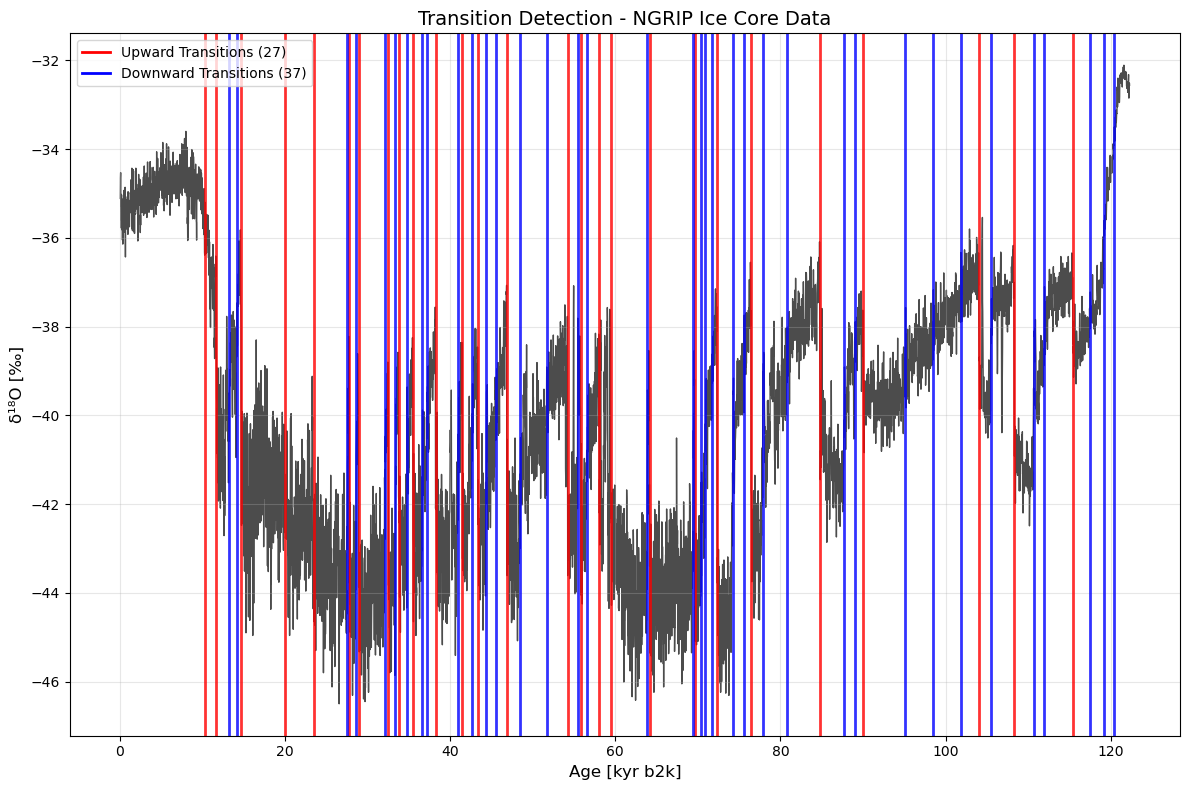

In [7]:
transitions.plot()

In [8]:
import os, ammonyte as amt
ngrip = amt.Series.from_csv(os.path.join(os.path.dirname(amt.__file__), 'data', 'NGRIP.csv'))
transitions = ngrip.kstest(w_min=0.12, w_max=2.5, n_w=15, d_c=0.77, n_c=3, s_c=2, x_c=0.8)
print(transitions)

Time axis values sorted in ascending order
Time axis values sorted in ascending order


Deterministic Transition Detection Results - NGRIP Ice Core Data
+----------+---------------------+----------------+------------------+---------------------+
| Method   |   Total Transitions |   Upward Jumps |   Downward Jumps | Series Label        |
+==========+=====================+================+==================+=====================+
| KS test  |                 104 |             49 |               55 | NGRIP Ice Core Data |
+----------+---------------------+----------------+------------------+---------------------+

Transition Details:
  1. Time: 8.14 kyr b2k, Direction: Upward, d_statistics: 0.4080, p_values: < 1e-8
  2. Time: 8.30 kyr b2k, Direction: Downward, d_statistics: 0.3760, p_values: < 1e-7
  3. Time: 10.20 kyr b2k, Direction: Upward, d_statistics: 0.9203, p_values: < 1e-56
  4. Time: 10.86 kyr b2k, Direction: Upward, d_statistics: 0.9680, p_values: < 1e-65
  5. Time: 11.52 kyr b2k, Direction: Downward, d_statistics: 0.9040, p_values: < 1e-53
  6. Time: 11.68 kyr b2k

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Transition Detection - NGRIP Ice Core Data'}, xlabel='Age [kyr b2k]', ylabel='δ¹⁸O [‰]'>)

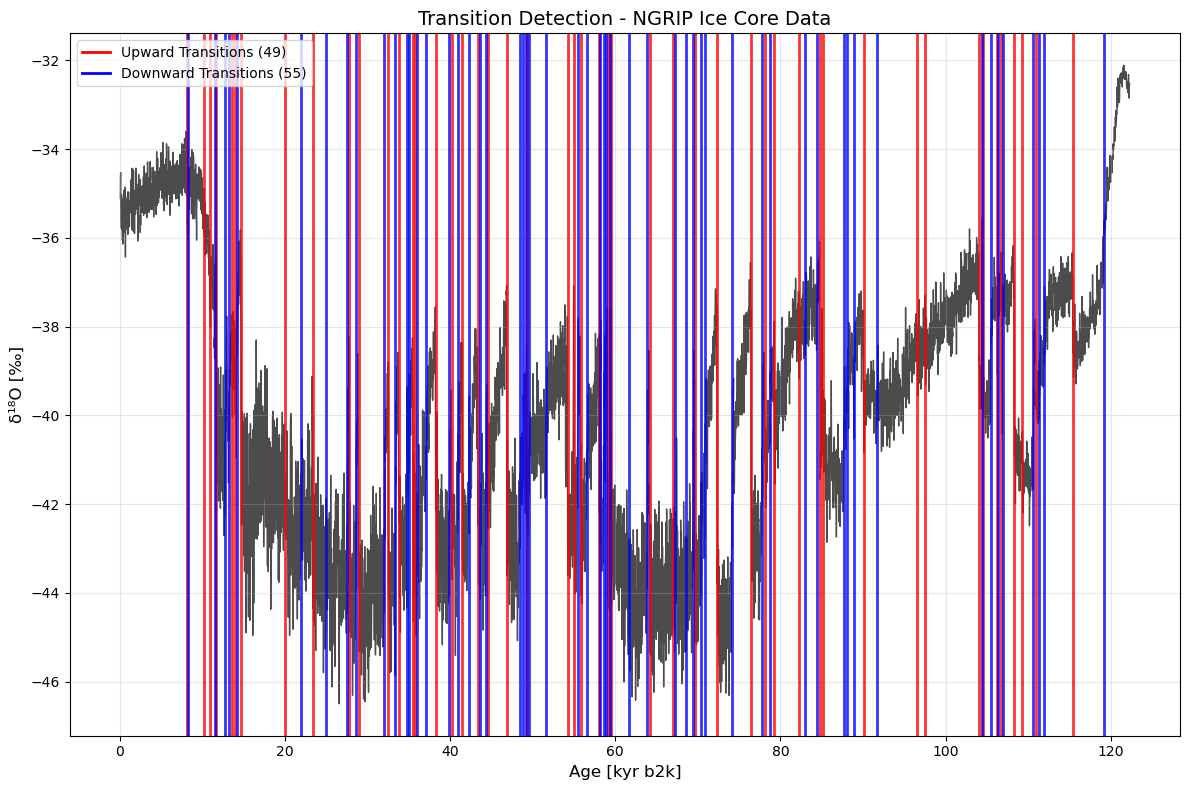

In [9]:
transitions.plot()

In [10]:
print(f"Number of transitions: {len(transitions.jump_times)}")
print(f"First transition: {transitions.jump_times[0]:.2f}")

Number of transitions: 104
First transition: 8.14
